In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 38.8 MB/s eta 0:00:00


In [3]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
import ultralytics
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
ultralytics.checks()

Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 42.9/112.6 GB disk)


In [8]:
model = YOLO("yolov9s.pt")

In [9]:
%%writefile road.yaml
path: ./drive/MyDrive/data
train: images/train
val: images/val

names:
  0: road sign
  1: traffic light

Overwriting road.yaml


In [10]:
results = model.train(data="road.yaml", model="yolov9s.pt", epochs=200, batch=8,
                      project='road', val=True, verbose=True, device='cuda:0')

Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=road.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov9s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plo


image 1/1 /content/drive/MyDrive/road_detection/test.jpg: 640x448 4 road signs, 1 traffic light, 96.9ms
Speed: 2.9ms preprocess, 96.9ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 448)


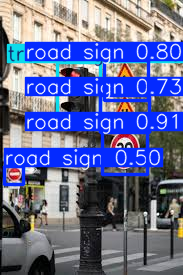

In [15]:
trained = YOLO('/content/runs/detect/road/train-2/weights/best.pt')
results = trained("/content/drive/MyDrive/road_detection/test.jpg")
result = results[0]
cv2_imshow(result.plot())


image 1/1 /content/drive/MyDrive/road_detection/test2.jpg: 448x640 1 road sign, 6 traffic lights, 20.9ms
Speed: 2.5ms preprocess, 20.9ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)


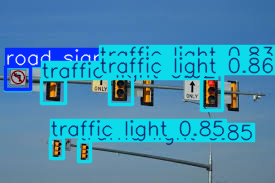

In [16]:
results = trained("/content/drive/MyDrive/road_detection/test2.jpg")
result = results[0]
cv2_imshow(result.plot())


image 1/1 /content/drive/MyDrive/road_detection/test3.jpg: 640x448 2 road signs, 1 traffic light, 26.8ms
Speed: 2.5ms preprocess, 26.8ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 448)


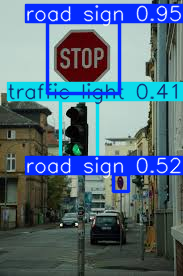

In [17]:
results = trained("/content/drive/MyDrive/road_detection/test3.jpg")
result = results[0]
cv2_imshow(result.plot())